In [11]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
%reload_ext autoreload


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from skfda import FDataGrid
from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.misc.regularization import L2Regularization
from skfda.misc.operators import LinearDifferentialOperator


from src.Smooth_Method.Smoothing_Spline import registration, lambda_finding, compute_smoothed_train
from src.MFPCA import run_mfpca
from src.Label import fit_gmm, label_merged, filter_candidates, take_iv, Youden_merged
from src.Smooth_Method.Regression_Spline import compute_smoothed_test
from src.Youden import knn_apply
from src.result_check import check_rmse, sweep_k
sensor_names = [
    "T2", "T24", "T30", "T50", "P2", "P15", "P30", "Nf", "Nc", "epr",
    "Ps30", "phi", "NRf", "NRc", "BPR", "farB", "htBleed", "Nfdmd", "PCNfRdmd", "W31", "W32"
]
base_names = ['unit_number', 'cycles', 'op1', 'op2', 'op3']
sensor_columns = base_names + sensor_names 

base_keep_names = ['unit_number', 'cycles']
SENSORS = ["T24", "T30", "T50", "P30", "Ps30", "phi", "BPR", "W31", "W32"]
sensor_keep_columns = base_keep_names + SENSORS
train_df = pd.read_csv('Data/train_FD001.txt', sep='\\s+', header=None, names=sensor_columns)
train_df = train_df[sensor_keep_columns]

test_df = pd.read_csv('Data/test_FD001.txt', sep='\\s+', header=None, names=sensor_columns)
test_df = test_df[sensor_keep_columns]

check_df = pd.read_csv('Data/RUL_FD001.txt', sep='\\s+', header=None, names=['RUL'])
check_df['unit_number'] = np.arange(1, len(check_df) + 1)



In [14]:
train_df = registration(train_df)

In [15]:
summary_lambdas, unit_cache = lambda_finding(train_df, SENSORS, cycle_col="t_registered")

  sensor    lambda        gcv
0    T24  0.012581   0.093138
1    T30  0.014806  16.366782
2    T50  0.005430  16.587771
3    P30  0.005976   0.170488
4   Ps30  0.004022   0.010600
5    phi  0.004822   0.093728
6    BPR  0.008878   0.000413
7    W31  0.010000   0.010471
8    W32  0.010113   0.003694


In [16]:
train_smoothed, coef_store = compute_smoothed_train(train_df, summary_lambdas, unit_cache, SENSORS)

Smoothed Dataframe :
       unit_number  t_registered         T24          T30          T50  \
0                1      0.000000  642.289657  1587.434701  1400.757907   
1                1      0.005236  642.291533  1587.410602  1400.722768   
2                1      0.010471  642.293403  1587.386568  1400.687608   
3                1      0.015707  642.295262  1587.362617  1400.652604   
4                1      0.020942  642.297102  1587.338764  1400.617936   
...            ...           ...         ...          ...          ...   
20626          100      0.979899  643.483922  1600.628724  1427.493349   
20627          100      0.984925  643.496300  1600.781270  1427.825041   
20628          100      0.989950  643.508681  1600.933899  1428.157030   
20629          100      0.994975  643.521066  1601.086555  1428.489083   
20630          100      1.000000  643.533456  1601.239188  1428.820966   

              P30       Ps30         phi       BPR        W31        W32  
0      554.1326

In [17]:
rho_score, exp_var = run_mfpca(train_smoothed, SENSORS)

   mfpc  explained_var_pct  cumulative_pct
0     1          95.084146       95.084146
1     2           2.107639       97.191786
2     3           0.753925       97.945710
3     4           0.481677       98.427387
4     5           0.427724       98.855111
5     6           0.344398       99.199509
6     7           0.303259       99.502769
7     8           0.193182       99.695951
8     9           0.160539       99.856490
9    10           0.072833       99.929323


In [18]:
label_train = fit_gmm(train_smoothed, rho_score)

label
0    65
1    35
Name: count, dtype: int64


In [19]:
label_train

,unit_number,label
0,1,0
1,2,1
2,3,1
3,4,0
4,5,1
...,...,...
95,96,0
96,97,1
97,98,1
98,99,0


In [20]:
iv_train = take_iv(train_smoothed, SENSORS)

In [21]:
youden_info = Youden_merged(label_train, iv_train)

In [22]:
youden_info
abc = []
for key, value in youden_info.items():
    abc.append(value['youden_J'])
mean_value = sum(abc) / len(abc)
print(mean_value)

0.9072039072039073


In [23]:
iv_test = take_iv(test_df, SENSORS)

In [24]:
label_test = label_merged(test_df, iv_test, youden_info, SENSORS)

label
0    62
1    38
Name: count, dtype: int64


In [25]:
candidates = filter_candidates(train_df, test_df, label_train, label_test)

[filter_candidates] 1/100 units fell back to the opposite group due to insufficient candidates :
  - unit 49: original_group=1, n_own_group=35, n_opposite_valid=4


In [26]:
candidates[1]

(    unit_number  cycles  label
 0             1     192      0
 3             4     189      0
 5             6     188      0
 7             8     150      0
 11           12     170      0
 ..          ...     ...    ...
 91           92     341      0
 93           94     258      0
 95           96     336      0
 98           99     185      0
 99          100     200      0
 
 [65 rows x 3 columns],
 np.int64(31))

In [27]:
smoothed_test = compute_smoothed_test(candidates, train_df, test_df, SENSORS)

In [28]:
# result = knn_apply(smoothed_test, train_df, train_smoothed, candidates, SENSORS, k=8)
result = knn_apply(smoothed_test, train_df, candidates, k=8)

In [29]:
compare_df, rmse = check_rmse(result, check_df)

In [30]:
# compare_df[compare_df['unit_number']==20]
compare_df.head(20)

,unit_number,RUL_pred_mean,RUL_pred_median,RUL
0,1,150.125,157.5,112
1,2,143.625,138.0,98
2,3,70.875,53.0,69
3,4,82.000,71.5,82
4,5,85.625,77.0,91
5,6,93.375,92.0,93
6,7,83.875,85.0,91
7,8,61.625,55.5,95
8,9,163.250,163.5,111
9,10,65.125,64.5,96


In [31]:
rmse


{'mean': np.float64(25.987097158974876),
 'median': np.float64(27.737654911689994)}

In [22]:
# sweep = sweep_k(result, compare_df)

In [24]:
def round_predictions_and_recount(df):
    """
    Hàm làm tròn các cột RUL dự đoán về số nguyên 
    và tính toán lại cột matches_count.
    """
    # 1. Làm tròn và ép kiểu về số nguyên (int)
    df['RUL_pred_mean'] = df['RUL_pred_mean'].round().astype(int)
    df['RUL_pred_median'] = df['RUL_pred_median'].round().astype(int)
    
    # 2. Đếm lại số lượng trùng khớp sau khi đã làm tròn
    df['matches_count_mean'] = (df['RUL_pred_mean'] == df['RUL']).astype(int)
    df['median']=(df['RUL_pred_median'] == df['RUL']).astype(int)
    
    return df

# Cách gọi hàm để áp dụng lên dataframe của bạn:
compare_df = round_predictions_and_recount(compare_df)

# Xem kết quả 5 dòng đầu
compare_df['matches_count_mean'].value_counts()


matches_count_mean
0    99
1     1
Name: count, dtype: int64

In [25]:
compare_df['median'].value_counts()

median
0    98
1     2
Name: count, dtype: int64

In [26]:
def normalize(candidates):
    results = {}

    for i in candidates:
        test_eval = candidates[i]['test_eval']
        candidate_evals = candidates[i]['candidate_evals']

        if len(candidate_evals) == 0:
            results[i] = {"error": "không có candidate để tính X_bar_j(t)"}
            continue

        all_candidate_arrays = np.stack(list(candidate_evals.values()))
        X_bar_j_t = np.mean(all_candidate_arrays, axis=0)
        u_test = test_eval / X_bar_j_t
        u_candidates = {
            uid: arr / X_bar_j_t for uid, arr in candidate_evals.items()
        }

        results[i] = {
            "u_test": u_test,
            "u_candidates": u_candidates,
        }

    return results


In [27]:
abc = normalize(smoothed_test)

In [28]:
def check_sensor_variance(normalized, sensor_cols):
    """
    Kiểm tra variance của từng sensor SAU khi normalize, để phát hiện
    sensor nào đang "trội" (có thể chi phối joint distance).

    Parameters
    ----------
    normalized : dict {i: {"u_test": ndarray(20,9), "u_candidates": {...}}}
        Từ normalize().
    sensor_cols : list[str]

    Returns
    -------
    pd.DataFrame -- cột: sensor, variance (sort giảm dần)
    """
    valid_u_test = [
        normalized[i]['u_test']
        for i in normalized
        if 'error' not in normalized[i]
    ]

    if len(valid_u_test) == 0:
        raise ValueError("Không có unit hợp lệ nào trong normalized")

    all_u_test = np.stack(valid_u_test)   # (n_test_units, 20, 9)
    variance_per_sensor = all_u_test.var(axis=(0, 1))

    result = pd.DataFrame({
        "sensor": sensor_cols,
        "variance": variance_per_sensor,
    }).sort_values("variance", ascending=False).reset_index(drop=True)

    return result

In [29]:
ccc = check_sensor_variance(abc, SENSORS)

In [30]:
ccc

,sensor,variance
0,T50,6.749795e-06
1,Ps30,5.368794e-06
2,W31,3.871824e-06
3,W32,3.719131e-06
4,BPR,3.390728e-06
5,T30,2.795378e-06
6,P30,4.707642e-07
7,phi,3.662537e-07
8,T24,1.109373e-07


In [78]:
from skfda.representation.basis import FDataBasis
import numpy as np

def compute_second_derivative(basis, coef, eval_grid):
    fd = FDataBasis(basis, coef.reshape(1, -1))
    fd_deriv2 = fd.derivative(order=2)
    values = fd_deriv2(eval_grid)
    return values[0, :, 0]

In [79]:
eval_grid = np.linspace(0, 1, 100)

unit_id = 1
sensor_name = "T24"

coef = coef_store[unit_id][sensor_name]["coef"]
basis = coef_store[unit_id][sensor_name]["basis"]

d2 = compute_second_derivative(basis, coef, eval_grid)
print(d2.shape)   # (100,)

(100,)


In [80]:
d2

array([ 1.09310768e-02, -4.14766159e-01, -8.40463395e-01, -1.26616063e+00,
       -1.69185787e+00, -2.14334113e+00, -2.65928947e+00, -3.17523780e+00,
       -3.69118614e+00, -4.20713447e+00, -4.13028903e+00, -3.60884824e+00,
       -3.08740746e+00, -2.56596668e+00, -2.04452590e+00, -1.39194880e+00,
       -7.17515656e-01, -4.30825092e-02,  6.31350638e-01,  1.20106355e+00,
        1.14245506e+00,  1.08384657e+00,  1.02523808e+00,  9.66629590e-01,
        9.48095436e-01,  9.82993731e-01,  1.01789203e+00,  1.05279032e+00,
        1.08768862e+00,  1.51351914e+00,  2.09572256e+00,  2.67792597e+00,
        3.26012939e+00,  3.84233281e+00,  4.26106814e+00,  4.67980348e+00,
        5.09853881e+00,  5.51727415e+00,  5.94283133e+00,  6.38544315e+00,
        6.82805497e+00,  7.27066679e+00,  7.71327861e+00,  7.69764361e+00,
        7.33832351e+00,  6.97900340e+00,  6.61968330e+00,  6.26036319e+00,
        5.86615175e+00,  5.46612509e+00,  5.06609843e+00,  4.66607177e+00,
        4.21857009e+00,  

In [81]:
def compute_all_second_derivatives(coef_store, sensor_cols, eval_grid):
    """
    Returns
    -------
    dict {unit_id: {sensor_name: ndarray(len(eval_grid),)}}
    """
    results = {}
    for unit_id, sensor_dict in coef_store.items():
        results[unit_id] = {}
        for sensor_name in sensor_cols:
            if sensor_name not in sensor_dict:
                continue
            coef = sensor_dict[sensor_name]["coef"]
            basis = sensor_dict[sensor_name]["basis"]
            results[unit_id][sensor_name] = compute_second_derivative(
                basis, coef, eval_grid
            )
    return results
def average_second_derivative_by_group(d2_results, label_train_df, sensor_cols,
                                         unit_col="unit_number"):
    """
    Parameters
    ----------
    d2_results : dict {unit_id: {sensor_name: ndarray}}
        Từ compute_all_second_derivatives.
    label_train_df : pd.DataFrame
        Cột: unit_number, label.

    Returns
    -------
    dict {label: {sensor_name: ndarray}} -- đường trung bình đạo hàm bậc 2
    mỗi nhóm, mỗi sensor.
    """
    label_map = dict(zip(label_train_df[unit_col], label_train_df["label"]))

    grouped = {0: {s: [] for s in sensor_cols}, 1: {s: [] for s in sensor_cols}}

    for unit_id, sensor_d2 in d2_results.items():
        label = label_map.get(unit_id)
        if label is None:
            continue
        for sensor_name, d2 in sensor_d2.items():
            grouped[label][sensor_name].append(d2)

    avg_result = {0: {}, 1: {}}
    for label in [0, 1]:
        for sensor_name in sensor_cols:
            arrs = grouped[label][sensor_name]
            if len(arrs) == 0:
                continue
            avg_result[label][sensor_name] = np.mean(np.stack(arrs), axis=0)

    return avg_result

In [82]:
eval_grid = np.linspace(0, 1, 100)

d2_results = compute_all_second_derivatives(coef_store, SENSORS, eval_grid)
avg_d2_by_group = average_second_derivative_by_group(d2_results, label_train, SENSORS)

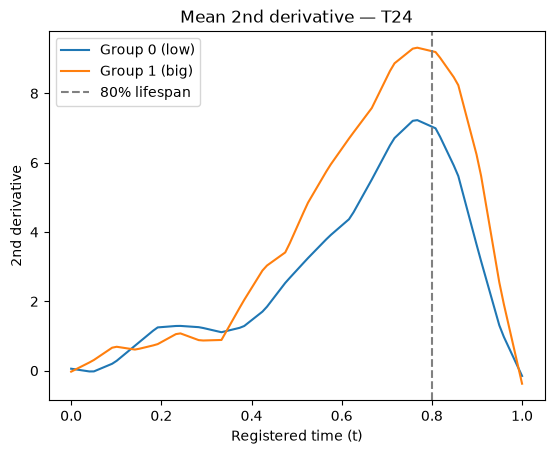

In [83]:
import matplotlib.pyplot as plt

sensor_to_plot = "T24"
plt.plot(eval_grid, avg_d2_by_group[0][sensor_to_plot], label="Group 0 (low)")
plt.plot(eval_grid, avg_d2_by_group[1][sensor_to_plot], label="Group 1 (big)")
plt.axvline(0.8, color="gray", linestyle="--", label="80% lifespan")
plt.xlabel("Registered time (t)")
plt.ylabel("2nd derivative")
plt.legend()
plt.title(f"Mean 2nd derivative — {sensor_to_plot}")
plt.show()

In [91]:
# def compute_alarm_points(rul_predictions, candidates, threshold=0.8):
#     """
#     Parameters
#     ----------
#     rul_predictions : dict {unit_id: RUL_pred} -- RUL_pred_mean hoặc weighted
#         đã tính từ validate()/knn_apply() ở pipeline chính.
#     candidates : dict {unit_id: (candidate_df, T_test)}

#     Returns
#     -------
#     pd.DataFrame -- unit_number, T_test, RUL_pred, alarm_cycle
#     """
#     rows = []
#     for uid, rul_pred in rul_predictions.items():
#         _, T_test = candidates[uid]
#         alarm_cycle = T_test + threshold * rul_pred
#         rows.append({
#             "unit_number": uid, "T_test": T_test,
#             "RUL_pred": rul_pred, "alarm_cycle": alarm_cycle,
#         })
#     return pd.DataFrame(rows)
def compute_alarm_points(rul_predictions, candidates, threshold=0.8):
    rows = []
    for uid, rul_pred in rul_predictions.items():
        _, T_test = candidates[uid]
        alarm_cycle = threshold * (T_test + rul_pred)   # đổi công thức
        rows.append({
            "unit_number": uid, "T_test": T_test,
            "RUL_pred": rul_pred, "alarm_cycle": alarm_cycle,
        })
    return pd.DataFrame(rows)

In [85]:
def evaluate_alarm_performance(alarm_df, check_df, unit_col="unit_number"):
    merged = alarm_df.merge(check_df, on=unit_col, how="inner")

    merged["true_failure_cycle"] = merged["T_test"] + merged["RUL"]
    merged["alarm_before_failure"] = merged["alarm_cycle"] < merged["true_failure_cycle"]
    merged["pct_life_at_alarm"] = merged["alarm_cycle"] / merged["true_failure_cycle"]

    pct_safe = merged["alarm_before_failure"].mean() * 100
    pct_last_20 = (merged["pct_life_at_alarm"] >= 0.8).mean() * 100
    pct_last_40 = (merged["pct_life_at_alarm"] >= 0.6).mean() * 100

    print(f"Alarms triggered before actual failure: {pct_safe:.1f}%")
    print(f"Alarms in last 20% of life: {pct_last_20:.1f}%")
    print(f"Alarms in last 40% of life: {pct_last_40:.1f}%")

    return merged

In [86]:
check_df

,RUL,unit_number
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5
...,...,...
95,137,96
96,82,97
97,59,98
98,117,99


In [94]:
def alarm_performance_table(merged):
    """
    Tạo bảng thống kê giống Table 5 của tác giả — dùng số lượng unit
    cụ thể (không phải %).

    Parameters
    ----------
    merged : pd.DataFrame
        Kết quả từ evaluate_alarm_performance(), cần có cột:
        'alarm_before_failure', 'pct_life_at_alarm'.

    Returns
    -------
    pd.DataFrame -- cột: Metric, Unit
    """
    n_total = len(merged)
    n_later = (~merged["alarm_before_failure"]).sum()
    n_earlier = merged["alarm_before_failure"].sum()

    n_last_40 = (merged["pct_life_at_alarm"] >= 0.60).sum()
    n_last_30 = (merged["pct_life_at_alarm"] >= 0.70).sum()
    n_last_20 = (merged["pct_life_at_alarm"] >= 0.80).sum()
    n_last_10 = (merged["pct_life_at_alarm"] >= 0.90).sum()
    n_last_5  = (merged["pct_life_at_alarm"] >= 0.95).sum()

    table = pd.DataFrame({
        "Metric": [
            "No of Total Test Engines",
            '"Alarm Point" is later than "True Failure Point"',
            '"Alarm Point" is earlier than "True Failure Point"',
            '"Alarm Point" is in last 40% of Total Life',
            '"Alarm Point" is in last 30% of Total Life',
            '"Alarm Point" is in last 20% of Total Life',
            '"Alarm Point" is in last 10% of Total Life',
            '"Alarm Point" is in last 5% of Total Life',
        ],
        "Unit": [
            n_total, n_later, n_earlier,
            n_last_40, n_last_30, n_last_20, n_last_10, n_last_5,
        ],
    })

    return table

In [95]:
table5 = alarm_performance_table(merged)
print(table5.to_string(index=False))

                                            Metric  Unit
                          No of Total Test Engines   100
  "Alarm Point" is later than "True Failure Point"    10
"Alarm Point" is earlier than "True Failure Point"    90
        "Alarm Point" is in last 40% of Total Life   100
        "Alarm Point" is in last 30% of Total Life    94
        "Alarm Point" is in last 20% of Total Life    61
        "Alarm Point" is in last 10% of Total Life    25
         "Alarm Point" is in last 5% of Total Life    12


In [3]:
from src.Plot.graph import plot_rul_comparison

In [32]:
compare_df

,unit_number,RUL_pred_mean,RUL_pred_median,RUL
0,1,150.125,157.5,112
1,2,143.625,138.0,98
2,3,70.875,53.0,69
3,4,82.000,71.5,82
4,5,85.625,77.0,91
...,...,...,...,...
95,96,146.250,140.0,137
96,97,74.000,70.5,82
97,98,79.375,75.5,59
98,99,120.250,114.0,117


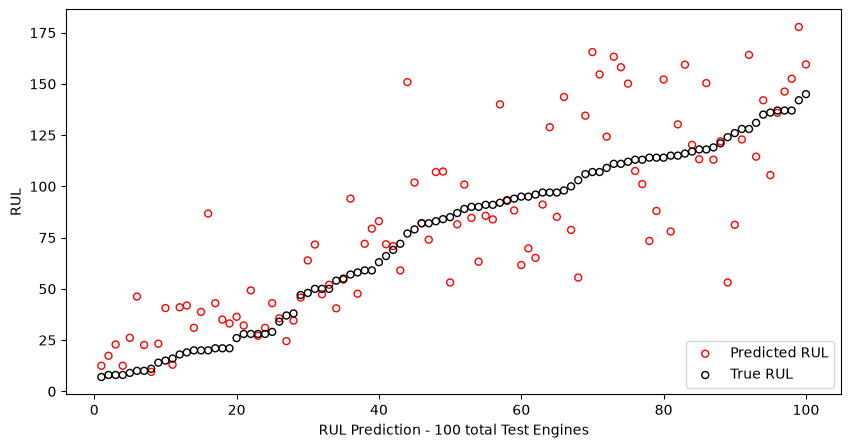

In [38]:
plot1 = plot_rul_comparison(compare_df, pred_col=['RUL_pred_mean'],true_col='RUL')

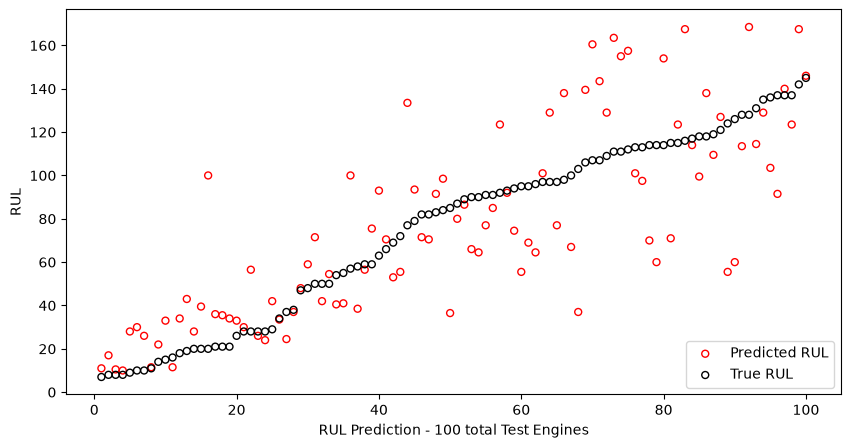

In [37]:
plot1 = plot_rul_comparison(compare_df, pred_col=['RUL_pred_median'],true_col='RUL')

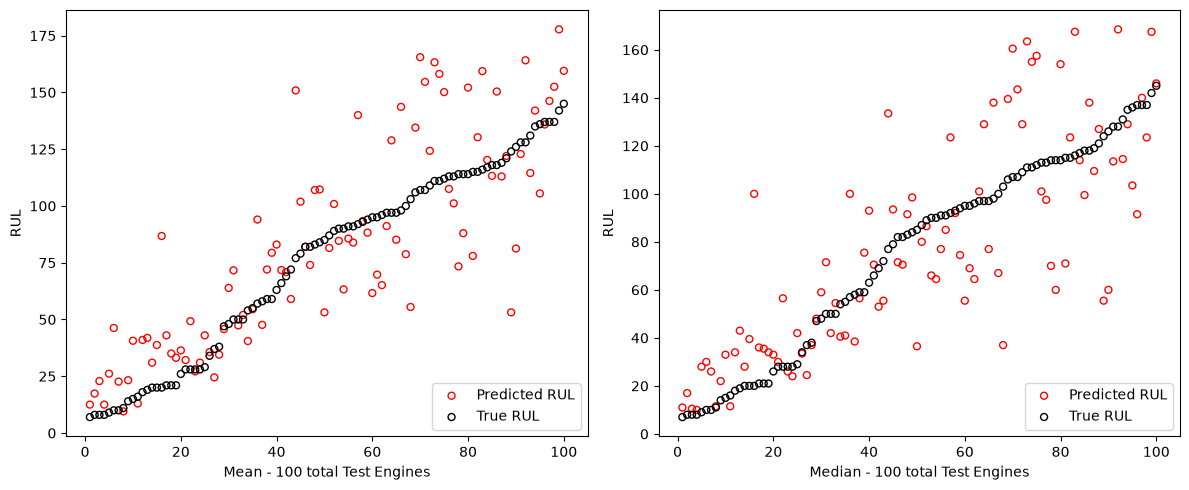

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_rul_comparison(compare_df, "RUL_pred_mean",true_col='RUL', title="Mean", ax=axes[0])
plot_rul_comparison(compare_df, "RUL_pred_median", true_col='RUL', title="Median", ax=axes[1])
plt.tight_layout()
plt.show()